# TSV (Trainable Steering Vector) Fine-Tuning on OpenCLIP
## Complete Runnable Guide for Google Colab

This notebook fine-tunes **OpenCLIP ViT-B/32** with **TSV (Trainable
Steering Vector)** — a lightweight technique that freezes the entire
backbone and trains a single small vector added to the residual stream at
one transformer layer, instead of attaching adapters to `Linear` layers
(as LoRA/VeRA/DoRA do).

It covers: data setup (cached in your own Drive so you don't re-download
every session), a single main TSV run, and a full 3-phase study sweeping
layer position, placement (`attn`/`mlp`/`residual`/combinations), and
steering strength -- with graphs and saved results for each.

## 1. Setup and Installation

In [1]:
# Mount Google Drive (needed later for saving results, and if your
# professor's dataset folder is shared into your own Drive)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
try:
    import gdown
    print("Required packages already present, skipping install.")
except ImportError:
    import subprocess
    import sys

    packages = [
        'transformers',
        'torch',
        'torchvision',
        'accelerate',
        'datasets',
        'numpy',
        'matplotlib',
        'tqdm',
        'scikit-learn',
        'gdown',
    ]

    print("Installing required packages...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade'] + packages)
    print("Installation complete!")


Required packages already present, skipping install.


In [3]:
# Verify GPU availability
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: NVIDIA A100-SXM4-80GB
GPU memory: 85.09 GB


## 2. Import Libraries and Setup

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import json
from datetime import datetime

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


## 3. Data Preparation

**Why this section is structured the way it is:** every second your Colab
runtime is connected to a GPU costs you compute quota, whether you're
downloading, training, or just fixing a typo. Re-downloading the dataset
from your professor's Drive folder on *every single session* wastes that
time for no reason. So the pattern here is:

1. **First time ever**: download once from your professor's shared Drive
   folder, then save a permanent copy into **your own** Drive.
2. **Every session after that**: just copy from your own Drive (same
   Google account -> fast, no real network download) instead of
   downloading from your professor's link again.
3. If your runtime disconnects and you reconnect, just re-run this
   section -- it will find the cached copy in your Drive and skip the
   slow path automatically.

In [5]:
import os
import shutil

# Your own Drive -- this is where we cache a permanent copy of the dataset
# so we never have to re-download it after the first time.
DRIVE_CACHE_DIR = '/content/drive/MyDrive/cifar10_cache'
DRIVE_CACHE_PATH = os.path.join(DRIVE_CACHE_DIR, 'cifar-10-batches-py')

# Where torchvision.datasets.CIFAR10 expects to find the data locally
LOCAL_DATA_DIR = 'data'
LOCAL_CACHE_PATH = os.path.join(LOCAL_DATA_DIR, 'cifar-10-batches-py')

os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

if os.path.exists(LOCAL_CACHE_PATH):
    # Already unpacked on THIS session's local disk (e.g. you re-ran this
    # cell without disconnecting) -- nothing to do.
    print(f"Already present locally at {LOCAL_CACHE_PATH}, skipping.")

elif os.path.exists(DRIVE_CACHE_PATH):
    # Fast path: we've cached this in your own Drive before. Copying
    # within Google's own storage is quick -- no external download.
    print("Found cached dataset in your Drive -- copying to local disk...")
    shutil.copytree(DRIVE_CACHE_PATH, LOCAL_CACHE_PATH)
    print(f"Copied to {LOCAL_CACHE_PATH}")

else:
    # Slow path, first time only: download from your professor's shared
    # Drive folder, then save a permanent copy into your own Drive for
    # every future session.
    print("Not cached yet -- downloading from professor's Drive folder...")
    folder_id = '1NZyI_UOHtSOlqpoivZqBiITy1hvM0Idc'
    !gdown --folder --id {folder_id}

    # See exactly what landed on disk before assuming a folder name --
    # if your professor's folder isn't literally named 'cifar-10-batches-py',
    # update `downloaded_name` below to match what gets printed here.
    print("Downloaded contents of current directory:", os.listdir('.'))
    downloaded_name = 'cifar-10-batches-py'

    if not os.path.exists(downloaded_name):
        raise FileNotFoundError(
            f"Couldn't find '{downloaded_name}' after download. Check the "
            f"directory listing printed above and update `downloaded_name` "
            f"to match what actually got downloaded."
        )

    # Move into place for torchvision
    shutil.move(downloaded_name, LOCAL_CACHE_PATH)
    print(f"Moved to {LOCAL_CACHE_PATH}")

    # Save a permanent copy to YOUR Drive so future sessions skip the
    # download entirely
    os.makedirs(DRIVE_CACHE_DIR, exist_ok=True)
    shutil.copytree(LOCAL_CACHE_PATH, DRIVE_CACHE_PATH)
    print(f"Cached a permanent copy to {DRIVE_CACHE_PATH} for next time.")

print("\nFinal local data contents:", os.listdir(LOCAL_DATA_DIR))


Found cached dataset in your Drive -- copying to local disk...
Copied to data/cifar-10-batches-py

Final local data contents: ['cifar-10-batches-py']


In [6]:
# Define data transformations
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

# Load CIFAR-10 dataset
# FIX: download=False now -- the data is already sitting in ./data from the
# Google Drive download above, so we don't need (or want) torchvision to
# reach out to the official site at all.
print("Loading CIFAR-10 dataset from local ./data ...")
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)

# Use subset for faster training
subset_size_train = 5000  # 10% of training data
subset_size_test = 1000   # 20% of test data

train_dataset, _ = random_split(
    train_dataset,
    [subset_size_train, len(train_dataset) - subset_size_train]
)

test_dataset, _ = random_split(
    test_dataset,
    [subset_size_test, len(test_dataset) - subset_size_test]
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of classes: 10")
print(f"Input shape: (3, 32, 32)")


Loading CIFAR-10 dataset from local ./data ...
Train dataset size: 5000
Test dataset size: 1000
Number of classes: 10
Input shape: (3, 32, 32)


In [7]:
# Create data loaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 79
Test batches: 16


## 4. Training and Evaluation Functions

In [8]:
def resize_images(images, target_size=224):
    """Resize CIFAR-10 images (32x32) to target size for ViT"""
    from torchvision.transforms import Resize
    resizer = Resize((target_size, target_size))
    return resizer(images)

def train_epoch(model, train_loader, optimizer, criterion, device, epoch, total_epochs):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}", leave=False)

    for images, labels in pbar:
        # Resize images for ViT
        images = resize_images(images, target_size=224)
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(images)
        loss = criterion(logits, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        # Update progress bar
        pbar.set_postfix({
            'loss': total_loss / (total / BATCH_SIZE),
            'acc': 100 * correct / total
        })

    return total_loss / len(train_loader), 100 * correct / total

def evaluate(model, test_loader, criterion, device):
    """Evaluate model on test set"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Evaluating", leave=False)
        for images, labels in pbar:
            # Resize images for ViT
            images = resize_images(images, target_size=224)
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            _, predicted = logits.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return total_loss / len(test_loader), accuracy, f1

def count_parameters(model):
    """Count trainable and total parameters"""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

print("Training and evaluation functions defined!")


Training and evaluation functions defined!


## 4.1 Global training hyperparameters

`EPOCHS = 10` is now used for **every** run in this notebook -- the main
run and every sweep -- instead of the shorter 3-epoch sweeps used before.
`LEARNING_RATE = 0.01` remains the default for the single main run below.
`LR_GRID` is new: instead of assuming one learning rate is right for every
layer configuration, the Layer/Grouping sweep (Phase 1) now tests all
three learning rates for every layer grouping, so we can tell whether a
layer looking "bad" is a real effect or just an artifact of the wrong LR
for that particular configuration.

In [9]:
EPOCHS = 10
LEARNING_RATE = 0.01
LR_GRID = [0.01, 0.001, 0.0005]

print(f"EPOCHS = {EPOCHS} (used for every run in this notebook)")
print(f"LEARNING_RATE = {LEARNING_RATE} (used for the single main run in Section 5)")
print(f"LR_GRID = {LR_GRID} (tested for every layer grouping in Phase 1)")


EPOCHS = 10 (used for every run in this notebook)
LEARNING_RATE = 0.01 (used for the single main run in Section 5)
LR_GRID = [0.01, 0.001, 0.0005] (tested for every layer grouping in Phase 1)


In [10]:
from datetime import datetime as _dt

# Every results file below is tagged with the dataset name and a run
# timestamp, so reruns NEVER overwrite previous results -- every run's
# output is kept, permanently, with no exceptions.
DATASET_NAME = 'cifar10'
RUN_TIMESTAMP = _dt.now().strftime('%Y%m%d_%H%M%S')

def save_name(base_name, ext):
    """e.g. save_name('tsv_full_study', 'json') -> 'tsv_full_study_cifar10_20260729_1432.json'"""
    return f"{base_name}_{DATASET_NAME}_{RUN_TIMESTAMP}.{ext}"

print(f"DATASET_NAME = {DATASET_NAME}")
print(f"RUN_TIMESTAMP = {RUN_TIMESTAMP}")
print(f"Results this run will be saved as e.g.: {save_name('tsv_full_study', 'json')}")


DATASET_NAME = cifar10
RUN_TIMESTAMP = 20260729_055227
Results this run will be saved as e.g.: tsv_full_study_cifar10_20260729_055227.json


## 5. TSV (Trainable Steering Vector) Fine-Tuning

TSV freezes the entire backbone and adds one small trainable vector `v`
directly to the **output of a transformer block** (the residual stream):

```
h_out = block(h_in)          # normal frozen block computation
h_out = h_out + lam * v      # TSV steering
```

Only `v` (and, for our classification setup, the linear classifier head)
is trained -- via a PyTorch **forward hook**, no need to modify the
model's source code or pick individual `Linear` sub-modules.

We apply this to **OpenCLIP ViT-B/32** (the LAION-trained CLIP vision
tower, available on the HF Hub as `laion/CLIP-ViT-B-32-laion2B-s34B-b79K`),
loaded through `transformers.CLIPVisionModel`.

In [11]:
from transformers import CLIPVisionModel

# OpenCLIP ViT-B/32 weights, hosted on the HF Hub and loadable via `transformers`
OPENCLIP_MODEL_NAME = 'laion/CLIP-ViT-B-32-laion2B-s34B-b79K'

# Load ONCE, just to inspect the module tree -- this tells us the exact
# attribute path to the transformer blocks (same exercise as timm's
# `model.blocks[i]` vs HF ViT's `model.vit.layers[i]`, but for CLIP).
_probe = CLIPVisionModel.from_pretrained(OPENCLIP_MODEL_NAME)
print(_probe)


config.json:   0%|          | 0.00/4.36k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
visual_projection.weight                                     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

CLIPVisionModel(
  (embeddings): CLIPVisionEmbeddings(
    (patch_embedding): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (position_embedding): Embedding(50, 768)
  )
  (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (encoder): CLIPEncoder(
    (layers): ModuleList(
      (0-11): 12 x CLIPEncoderLayer(
        (self_attn): CLIPAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): CLIPMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        )
        (

In [12]:
# Reading the tree printed above: CLIPVisionModel -> encoder -> layers[i]
# (NOTE: this is specific to the current `transformers` version. Older
# versions wrapped it as `model.vision_model.encoder.layers[i]` instead --
# always confirm with print(model) rather than assuming the path.)
print(_probe.encoder.layers[0])

# Done inspecting -- free the memory before building the real model below.
del _probe


CLIPEncoderLayer(
  (self_attn): CLIPAttention(
    (k_proj): Linear(in_features=768, out_features=768, bias=True)
    (v_proj): Linear(in_features=768, out_features=768, bias=True)
    (q_proj): Linear(in_features=768, out_features=768, bias=True)
    (out_proj): Linear(in_features=768, out_features=768, bias=True)
  )
  (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): CLIPMLP(
    (activation_fn): GELUActivation()
    (fc1): Linear(in_features=768, out_features=3072, bias=True)
    (fc2): Linear(in_features=3072, out_features=768, bias=True)
  )
  (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


In [13]:
def get_transformer_blocks(model):
    """
    Return the list/ModuleList of transformer blocks for common ViT/CLIP
    implementations, so the rest of the code doesn't care which library the
    backbone came from.

    Covers:
      - timm ViT:                        model.blocks[i]
      - HF ViTModel:                      model.vit.layers[i]
      - HF CLIPVisionModel (current):     model.encoder.layers[i]
      - HF CLIPVisionModel (older ver.):  model.vision_model.encoder.layers[i]
      - open_clip (the `open_clip` pip package): model.visual.transformer.resblocks[i]
    """
    if hasattr(model, 'blocks'):                                        # timm
        return model.blocks
    if hasattr(model, 'vit') and hasattr(model.vit, 'layers'):           # HF ViTForImageClassification
        return model.vit.layers
    if hasattr(model, 'vision_model'):                                   # HF CLIPVisionModel (older versions)
        return model.vision_model.encoder.layers
    if hasattr(model, 'encoder') and hasattr(model.encoder, 'layers'):   # HF CLIPVisionModel (current) / generic
        return model.encoder.layers
    if hasattr(model, 'visual') and hasattr(model.visual, 'transformer'):  # open_clip package
        return model.visual.transformer.resblocks
    if hasattr(model, 'backbone'):                                       # our own wrapper classes
        return get_transformer_blocks(model.backbone)
    raise ValueError(
        "Could not auto-detect transformer blocks. "
        "Run print(model) and locate the block list manually."
    )


class TSVHookManager(nn.Module):
    """
    Registers forward hooks that add a trainable steering vector `v`
    (scaled by `lam`) to the output of chosen transformer blocks.

    where:
        'residual'      -> add v to the WHOLE block's output (default, matches the TSV paper)
        'attn'          -> add v only to the self-attention sub-module's output
        'mlp'           -> add v only to the MLP sub-module's output
        'attn_mlp'      -> two separate vectors, one after attn, one after mlp
        'attn_residual' -> two separate vectors, one after attn, one after the whole block's output
        'mlp_residual'  -> two separate vectors, one after mlp, one after the whole block's output

    layer_indices:
        list of block indices to steer, e.g. [4] for a single early-middle
        layer, or list(range(num_layers)) to steer every layer.
    """
    def __init__(self, model, layer_indices, hidden_dim, lam=5.0, where='residual'):
        super().__init__()
        self.lam = lam
        self.where = where
        self._hook_handles = []
        self.tsv_vectors = nn.ParameterDict()

        blocks = get_transformer_blocks(model)

        for idx in layer_indices:
            block = blocks[idx]

            if where == 'residual':
                v = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_res'] = v
                self._hook_handles.append(block.register_forward_hook(self._make_hook(v)))

            elif where == 'attn':
                sub = self._find_submodule(block, ['attn', 'attention', 'self_attn'])
                v = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_attn'] = v
                self._hook_handles.append(sub.register_forward_hook(self._make_hook(v)))

            elif where == 'mlp':
                sub = self._find_submodule(block, ['mlp', 'feed_forward', 'ffn'])
                v = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_mlp'] = v
                self._hook_handles.append(sub.register_forward_hook(self._make_hook(v)))

            elif where == 'attn_mlp':
                attn_sub = self._find_submodule(block, ['attn', 'attention', 'self_attn'])
                mlp_sub = self._find_submodule(block, ['mlp', 'feed_forward', 'ffn'])
                v_attn = nn.Parameter(torch.zeros(hidden_dim))
                v_mlp = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_attn'] = v_attn
                self.tsv_vectors[f'layer{idx}_mlp'] = v_mlp
                self._hook_handles.append(attn_sub.register_forward_hook(self._make_hook(v_attn)))
                self._hook_handles.append(mlp_sub.register_forward_hook(self._make_hook(v_mlp)))

            elif where == 'attn_residual':
                attn_sub = self._find_submodule(block, ['attn', 'attention', 'self_attn'])
                v_attn = nn.Parameter(torch.zeros(hidden_dim))
                v_res = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_attn'] = v_attn
                self.tsv_vectors[f'layer{idx}_res'] = v_res
                self._hook_handles.append(attn_sub.register_forward_hook(self._make_hook(v_attn)))
                self._hook_handles.append(block.register_forward_hook(self._make_hook(v_res)))

            elif where == 'mlp_residual':
                mlp_sub = self._find_submodule(block, ['mlp', 'feed_forward', 'ffn'])
                v_mlp = nn.Parameter(torch.zeros(hidden_dim))
                v_res = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_mlp'] = v_mlp
                self.tsv_vectors[f'layer{idx}_res'] = v_res
                self._hook_handles.append(mlp_sub.register_forward_hook(self._make_hook(v_mlp)))
                self._hook_handles.append(block.register_forward_hook(self._make_hook(v_res)))

            else:
                raise ValueError(f"Unknown 'where' option: {where}")

    def _make_hook(self, v):
        def hook(module, inputs, output):
            # Some sub-modules (e.g. attention) return a tuple like
            # (hidden_states, attn_weights); only steer the hidden_states.
            if isinstance(output, tuple):
                hidden_states = output[0] + self.lam * v
                return (hidden_states,) + output[1:]
            return output + self.lam * v
        return hook

    @staticmethod
    def _find_submodule(block, candidate_names):
        for name in candidate_names:
            if hasattr(block, name):
                return getattr(block, name)
        raise AttributeError(
            f"None of {candidate_names} found on block. "
            f"Inspect it with print(block) to find the right attribute name."
        )

    def remove_hooks(self):
        for h in self._hook_handles:
            h.remove()
        self._hook_handles = []

print("get_transformer_blocks() and TSVHookManager (6 placement modes) defined!")


get_transformer_blocks() and TSVHookManager (6 placement modes) defined!


In [14]:
class TSVClassificationModel(nn.Module):
    """
    Frozen OpenCLIP ViT-B/32 vision tower + trainable TSV steering vector(s)
    + a trainable linear classification head.

    Only `self.tsv` and `self.classifier` show up in trainable_parameters() --
    the backbone itself is entirely frozen, same spirit as PEFT, but the
    'adapter' here is a steering vector added to the residual stream instead
    of a low-rank update to a Linear layer.
    """
    def __init__(self, model_name=OPENCLIP_MODEL_NAME, num_classes=10,
                 layer_indices=None, lam=5.0, where='residual'):
        super().__init__()
        self.backbone = CLIPVisionModel.from_pretrained(model_name)
        self.hidden_size = self.backbone.config.hidden_size
        num_layers = self.backbone.config.num_hidden_layers

        # Freeze the ENTIRE backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        # Default: one early-middle layer, matching the TSV paper's finding
        # that layers ~4-10 (out of ~12-32) work best for steering.
        if layer_indices is None:
            layer_indices = [num_layers // 3]

        self.tsv = TSVHookManager(
            self.backbone, layer_indices, self.hidden_size,
            lam=lam, where=where
        )

        self.classifier = nn.Linear(self.hidden_size, num_classes)

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values)
        cls_output = outputs.last_hidden_state[:, 0, :]  # CLS / class token, final layer
        logits = self.classifier(cls_output)
        return logits

    def trainable_parameters(self):
        return list(self.tsv.parameters()) + list(self.classifier.parameters())

print("TSVClassificationModel defined!")


TSVClassificationModel defined!


In [15]:
print("\n" + "="*60)
print("TSV FINE-TUNING")
print("="*60)

# Build the TSV model: single early-middle layer (auto-picked), steering the
# residual stream (where='residual') -- the default/simplest TSV setup.
tsv_model = TSVClassificationModel(
    model_name=OPENCLIP_MODEL_NAME,
    num_classes=10,
    layer_indices=None,   # None -> auto picks an early-middle layer
    lam=5.0,
    where='residual'
)
tsv_model = tsv_model.to(device)

trainable = sum(p.numel() for p in tsv_model.trainable_parameters())
total = sum(p.numel() for p in tsv_model.parameters())
print(f"\nTSV Model Summary:")
print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Parameter efficiency: {100 * trainable / total:.4f}%")



TSV FINE-TUNING


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
visual_projection.weight                                     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11


TSV Model Summary:
Total parameters: 87,464,458
Trainable parameters: 8,458
Parameter efficiency: 0.0097%


In [16]:
# Training setup for TSV (EPOCHS / LEARNING_RATE come from section 5.1)
# NOTE: optimizer only sees tsv_model.trainable_parameters() -- the TSV
# vector(s) + classifier head. Everything else in the backbone is frozen
# and never passed to the optimizer at all.
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(tsv_model.trainable_parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

tsv_history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
    'test_f1': []
}

best_acc = 0
start_time = datetime.now()

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(tsv_model, train_loader, optimizer, criterion, device, epoch, EPOCHS)
    test_loss, test_acc, test_f1 = evaluate(tsv_model, test_loader, criterion, device)
    scheduler.step()

    tsv_history['train_loss'].append(train_loss)
    tsv_history['train_acc'].append(train_acc)
    tsv_history['test_loss'].append(test_loss)
    tsv_history['test_acc'].append(test_acc)
    tsv_history['test_f1'].append(test_f1)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | F1: {test_f1:.4f}")

    if test_acc > best_acc:
        best_acc = test_acc
        # No PEFT save_pretrained() here -- just save the small state dicts directly
        os.makedirs('./tsv_best_model', exist_ok=True)
        torch.save(tsv_model.tsv.state_dict(), './tsv_best_model/tsv_vectors.pth')
        torch.save(tsv_model.classifier.state_dict(), './tsv_best_model/classifier_head.pth')
        print(f"  ✓ TSV vector(s) + classifier head saved (best accuracy: {best_acc:.2f}%)")

training_time_tsv = (datetime.now() - start_time).total_seconds()
print(f"\nTSV Training completed in {training_time_tsv:.2f} seconds")
print(f"Best Test Accuracy: {best_acc:.2f}%")


Epoch 1/10
  Train Loss: 0.5496 | Train Acc: 82.66%
  Test Loss: 0.3516 | Test Acc: 89.30% | F1: 0.8940
  ✓ TSV vector(s) + classifier head saved (best accuracy: 89.30%)


Epoch 2/10
  Train Loss: 0.3470 | Train Acc: 88.54%
  Test Loss: 0.3488 | Test Acc: 88.50% | F1: 0.8847


Epoch 3/10
  Train Loss: 0.3512 | Train Acc: 87.80%
  Test Loss: 0.3247 | Test Acc: 89.20% | F1: 0.8933


Epoch 4/10
  Train Loss: 0.3296 | Train Acc: 88.62%
  Test Loss: 0.3294 | Test Acc: 88.80% | F1: 0.8867


Epoch 5/10
  Train Loss: 0.2438 | Train Acc: 91.74%
  Test Loss: 0.2199 | Test Acc: 93.30% | F1: 0.9323
  ✓ TSV vector(s) + classifier head saved (best accuracy: 93.30%)


Epoch 6/10
  Train Loss: 0.1931 | Train Acc: 93.44%
  Test Loss: 0.1502 | Test Acc: 95.30% | F1: 0.9527
  ✓ TSV vector(s) + classifier head saved (best accuracy: 95.30%)


Epoch 7/10
  Train Loss: 0.1472 | Train Acc: 94.84%
  Test Loss: 0.1328 | Test Acc: 95.70% | F1: 0.9568
  ✓ TSV vector(s) + classifier head saved (best accuracy: 95.70%)


Epoch 8/10
  Train Loss: 0.1058 | Train Acc: 96.46%
  Test Loss: 0.1486 | Test Acc: 95.50% | F1: 0.9549


Epoch 9/10
  Train Loss: 0.0916 | Train Acc: 96.94%
  Test Loss: 0.1126 | Test Acc: 95.70% | F1: 0.9569


Epoch 10/10
  Train Loss: 0.0861 | Train Acc: 97.32%
  Test Loss: 0.1060 | Test Acc: 96.10% | F1: 0.9610
  ✓ TSV vector(s) + classifier head saved (best accuracy: 96.10%)

TSV Training completed in 85.49 seconds
Best Test Accuracy: 96.10%


## 5.1 Full TSV Study: Layer Position, Placement, Strength, and Learning Rate

Same three questions as before -- **which layer(s), which placement, which
steering strength** -- but now:

- **Every run uses `EPOCHS=10`** instead of the earlier fast 3-epoch
  sweeps, to rule out "just needed more training" as an explanation for
  weak-looking configurations.
- **Phase 1 (Layer/Grouping) now also sweeps `LR_GRID`** for every one of
  the 36 groupings -- 36 x 3 = **108 runs** -- so we can tell whether a
  layer combination looking bad is a genuine steering-collapse effect, or
  just the wrong learning rate for that specific configuration.
- Phases 2-5 reuse whichever `(layer grouping, learning rate)` combination
  Phase 1 finds best, then vary placement / strength / training set size /
  batch size one at a time, same discipline as before.
- The old separate "Learning Rate Sweep" phase is removed -- redundant now
  that LR is tested properly, per-layer, in Phase 1 itself.

**Total for this section: 108 + 6 + 5 = 119 runs, all at 10 epochs.**

In [17]:
import time

def run_tsv_experiment(layer_indices, where, lam, epochs, lr, train_loader_to_use=None, verbose=True):
    """Train ONE TSV configuration end-to-end and return its result metrics.
    Frees GPU memory before returning so a long sweep doesn't accumulate.
    Defaults to the global train_loader if none is given."""
    loader = train_loader_to_use if train_loader_to_use is not None else train_loader

    m = TSVClassificationModel(model_name=OPENCLIP_MODEL_NAME, num_classes=10,
                                layer_indices=layer_indices, lam=lam, where=where).to(device)
    opt = optim.AdamW(m.trainable_parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()

    start = time.time()
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(m, loader, opt, crit, device, epoch, epochs)
        if verbose:
            print(f"      epoch {epoch+1}/{epochs}: train_loss={train_loss:.4f}  train_acc={train_acc:.2f}%")
    elapsed = time.time() - start

    _, test_acc, test_f1 = evaluate(m, test_loader, crit, device)
    trainable_params = sum(p.numel() for p in m.trainable_parameters())

    del m, opt
    torch.cuda.empty_cache()

    result = {
        'layer_indices': layer_indices, 'where': where, 'lam': lam, 'lr': lr,
        'test_acc': test_acc, 'test_f1': test_f1,
        'trainable_params': trainable_params, 'time_seconds': elapsed,
    }
    if verbose:
        print(f"    layers={layer_indices}  where={where}  lam={lam}  lr={lr}  "
              f"-> acc={test_acc:.2f}%  f1={test_f1:.4f}  ({elapsed:.1f}s)")
    return result


# --- Build all 36 layer groupings (1-indexed labels, 0-indexed internally) ---
num_layers = tsv_model.backbone.config.num_hidden_layers  # 12 for ViT-B/32
layer_groups = {}

for L in range(1, num_layers + 1):                      # each single layer
    layer_groups[f'L{L}'] = [L - 1]

layer_groups['All(L1-12)'] = list(range(num_layers))     # all layers

for L in range(1, num_layers):                           # 2 adjacent layers
    layer_groups[f'L{L}-{L+1}'] = [L - 1, L]

for L in range(1, num_layers - 1):                        # 3 adjacent layers
    layer_groups[f'L{L}-{L+1}-{L+2}'] = [L - 1, L, L + 1]

layer_groups['FirstHalf(L1-6)'] = list(range(0, 6))
layer_groups['SecondHalf(L7-12)'] = list(range(6, 12))

wheres = ['residual', 'attn', 'mlp', 'attn_mlp', 'attn_residual', 'mlp_residual']
lams = [0.1, 0.5, 1, 5, 10]

print(f"Layer groupings to test: {len(layer_groups)}")
print(f"Learning rates per grouping: {len(LR_GRID)}")
print(f"Phase 1 total runs: {len(layer_groups)} x {len(LR_GRID)} = {len(layer_groups) * len(LR_GRID)}")


Layer groupings to test: 36
Learning rates per grouping: 3
Phase 1 total runs: 36 x 3 = 108


### Phase 1: Layer / Grouping x Learning Rate Sweep (108 runs, `where='residual'`, `lam=5.0` fixed, `EPOCHS=10`)

In [18]:
phase1_results = []

print("="*70)
print(f"PHASE 1: LAYER/GROUPING x LEARNING RATE SWEEP  (where='residual', lam=5.0 fixed, epochs={EPOCHS})")
print(f"Testing {len(layer_groups)} layer groupings x {len(LR_GRID)} learning rates = "
      f"{len(layer_groups) * len(LR_GRID)} runs")
print("="*70)

phase1_start = time.time()
for name, layers in layer_groups.items():
    print(f"\n--- {name}  (layer_indices={layers}) ---")
    for lr in LR_GRID:
        result = run_tsv_experiment(layer_indices=layers, where='residual', lam=5.0, epochs=EPOCHS, lr=lr)
        result['name'] = name
        phase1_results.append(result)

phase1_elapsed = time.time() - phase1_start
print(f"\nPhase 1 total time: {phase1_elapsed/60:.1f} minutes")

best_phase1 = max(phase1_results, key=lambda r: r['test_acc'])
print(f"\nBest layer grouping + LR: {best_phase1['name']} (layers={best_phase1['layer_indices']}), "
      f"lr={best_phase1['lr']} -> {best_phase1['test_acc']:.2f}% acc, F1={best_phase1['test_f1']:.4f}")


PHASE 1: LAYER/GROUPING x LEARNING RATE SWEEP  (where='residual', lam=5.0 fixed, epochs=10)
Testing 36 layer groupings x 3 learning rates = 108 runs

--- L1  (layer_indices=[0]) ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
visual_projection.weight                                     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

      epoch 1/10: train_loss=0.4631  train_acc=85.62%


      epoch 2/10: train_loss=0.2763  train_acc=90.64%


...

      epoch 7/10: train_loss=0.1417  train_acc=95.26%


      epoch 8/10: train_loss=0.1436  train_acc=95.14%


      epoch 9/10: train_loss=0.1254  train_acc=95.54%


      epoch 10/10: train_loss=0.1397  train_acc=95.18%


    layers=[6, 7, 8, 9, 10, 11]  where=residual  lam=5.0  lr=0.0005  -> acc=95.40%  f1=0.9540  (68.6s)

Phase 1 total time: 126.3 minutes

Best layer grouping + LR: L1-2 (layers=[0, 1]), lr=0.001 -> 97.10% acc, F1=0.9709


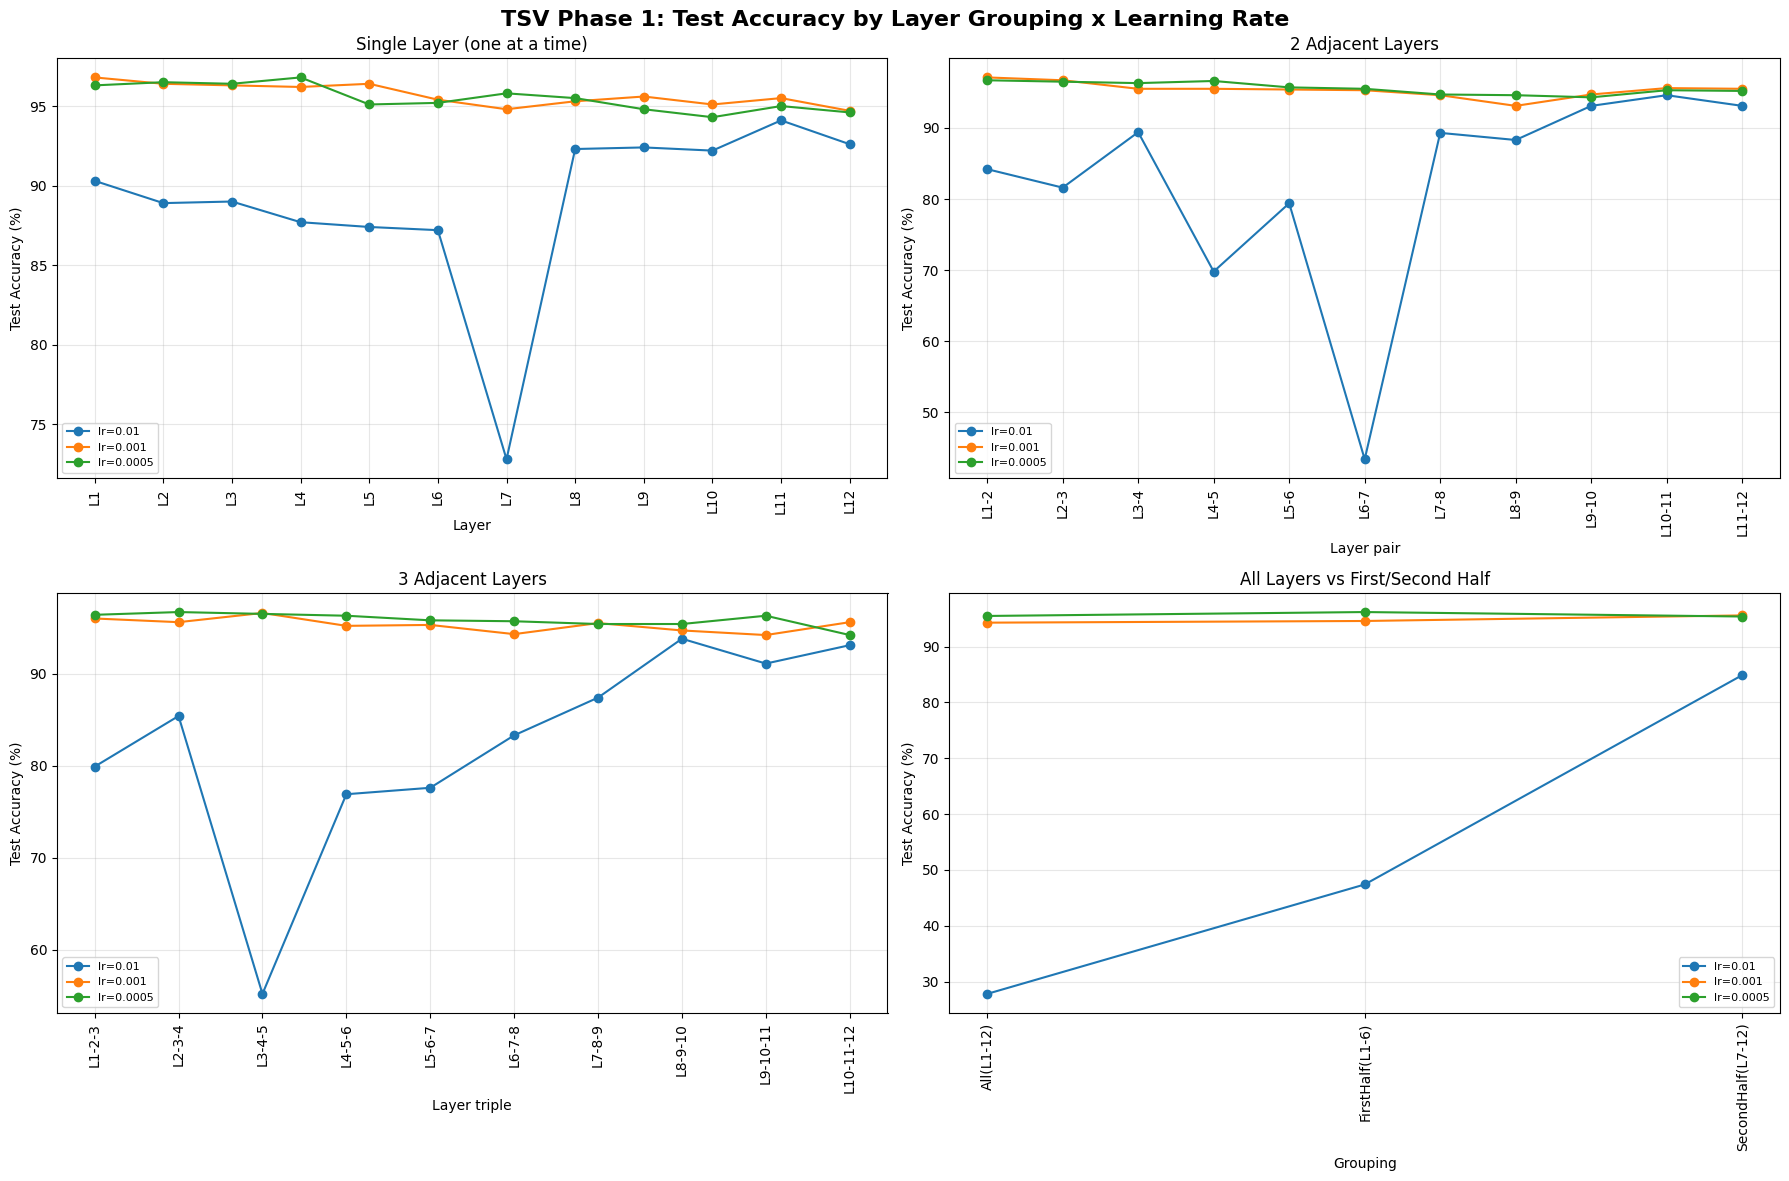


Top 10 (layer grouping, learning rate) combinations by accuracy:
  L1-2                 lr=0.001    acc=97.10%  f1=0.9709  params=9,226
  L1                   lr=0.001    acc=96.80%  f1=0.9680  params=8,458
  L4                   lr=0.0005   acc=96.80%  f1=0.9680  params=8,458
  L1-2                 lr=0.0005   acc=96.70%  f1=0.9668  params=9,226
  L2-3                 lr=0.001    acc=96.70%  f1=0.9671  params=9,226
  L2-3-4               lr=0.0005   acc=96.70%  f1=0.9670  params=9,994
  L4-5                 lr=0.0005   acc=96.60%  f1=0.9659  params=9,226
  L3-4-5               lr=0.001    acc=96.60%  f1=0.9661  params=9,994
  L2                   lr=0.0005   acc=96.50%  f1=0.9650  params=8,458
  L2-3                 lr=0.0005   acc=96.50%  f1=0.9649  params=9,226

Did the LR that won change by grouping category? (best LR within each category)
  Singles    best: L1 @ lr=0.001 -> 96.80%
  Pairs      best: L1-2 @ lr=0.001 -> 97.10%
  Triples    best: L2-3-4 @ lr=0.0005 -> 96.70%
  Speci

In [19]:
# Phase 1 results: for each grouping category, one line PER learning rate,
# so we can see whether a layer looking "bad" depends on which LR it used.
singles  = [r for r in phase1_results if r['name'].startswith('L') and '-' not in r['name']]
pairs    = [r for r in phase1_results if r['name'].startswith('L') and r['name'].count('-') == 1]
triples  = [r for r in phase1_results if r['name'].startswith('L') and r['name'].count('-') == 2]
specials = [r for r in phase1_results if r['name'] in ('All(L1-12)', 'FirstHalf(L1-6)', 'SecondHalf(L7-12)')]

def plot_group(ax, group_results, title, xlabel):
    names_order = list(dict.fromkeys(r['name'] for r in group_results))  # preserve first-seen order
    for lr in LR_GRID:
        ys = [next(r['test_acc'] for r in group_results if r['name'] == n and r['lr'] == lr) for n in names_order]
        ax.plot(names_order, ys, marker='o', label=f'lr={lr}')
    ax.set_title(title)
    ax.set_xlabel(xlabel); ax.set_ylabel('Test Accuracy (%)')
    ax.tick_params(axis='x', rotation=90); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('TSV Phase 1: Test Accuracy by Layer Grouping x Learning Rate', fontsize=16, fontweight='bold')

plot_group(axes[0,0], singles, 'Single Layer (one at a time)', 'Layer')
plot_group(axes[0,1], pairs, '2 Adjacent Layers', 'Layer pair')
plot_group(axes[1,0], triples, '3 Adjacent Layers', 'Layer triple')
plot_group(axes[1,1], specials, 'All Layers vs First/Second Half', 'Grouping')

plt.tight_layout()
plt.savefig('tsv_phase1_layer_groupings.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 (layer grouping, learning rate) combinations by accuracy:")
for r in sorted(phase1_results, key=lambda r: -r['test_acc'])[:10]:
    print(f"  {r['name']:<20} lr={r['lr']:<8} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}  params={r['trainable_params']:,}")

print("\nDid the LR that won change by grouping category? (best LR within each category)")
for cat_name, cat_results in [('Singles', singles), ('Pairs', pairs), ('Triples', triples), ('Specials', specials)]:
    best_in_cat = max(cat_results, key=lambda r: r['test_acc'])
    print(f"  {cat_name:<10} best: {best_in_cat['name']} @ lr={best_in_cat['lr']} -> {best_in_cat['test_acc']:.2f}%")


### Phase 2: Placement (`where`) Sweep (6 runs, best layer grouping + learning rate from Phase 1, `lam=5.0` fixed, `EPOCHS=10`)

In [20]:
best_layers = best_phase1['layer_indices']
best_layers_name = best_phase1['name']
best_lr = best_phase1['lr']
phase2_results = []

print("="*70)
print(f"PHASE 2: PLACEMENT ('where') SWEEP  (layers={best_layers} [{best_layers_name}], lr={best_lr}, lam=5.0 fixed, epochs={EPOCHS})")
print("="*70)

phase2_start = time.time()
for w in wheres:
    print(f"\n--- where='{w}' ---")
    result = run_tsv_experiment(layer_indices=best_layers, where=w, lam=5.0, epochs=EPOCHS, lr=best_lr)
    result['name'] = w
    phase2_results.append(result)

phase2_elapsed = time.time() - phase2_start
print(f"\nPhase 2 total time: {phase2_elapsed/60:.1f} minutes")

best_phase2 = max(phase2_results, key=lambda r: r['test_acc'])
print(f"\nBest placement: where='{best_phase2['where']}' -> {best_phase2['test_acc']:.2f}% acc, F1={best_phase2['test_f1']:.4f}")


PHASE 2: PLACEMENT ('where') SWEEP  (layers=[0, 1] [L1-2], lr=0.001, lam=5.0 fixed, epochs=10)

--- where='residual' ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
visual_projection.weight                                     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

      epoch 1/10: train_loss=1.0275  train_acc=83.52%


      epoch 2/10: train_loss=0.2934  train_acc=94.16%


...

      epoch 7/10: train_loss=0.1806  train_acc=94.54%


      epoch 8/10: train_loss=0.1731  train_acc=94.50%


      epoch 9/10: train_loss=0.1683  train_acc=94.84%


      epoch 10/10: train_loss=0.1605  train_acc=94.88%


    layers=[0, 1]  where=mlp_residual  lam=5.0  lr=0.001  -> acc=94.70%  f1=0.9468  (82.2s)

Phase 2 total time: 8.5 minutes

Best placement: where='residual' -> 97.10% acc, F1=0.9710


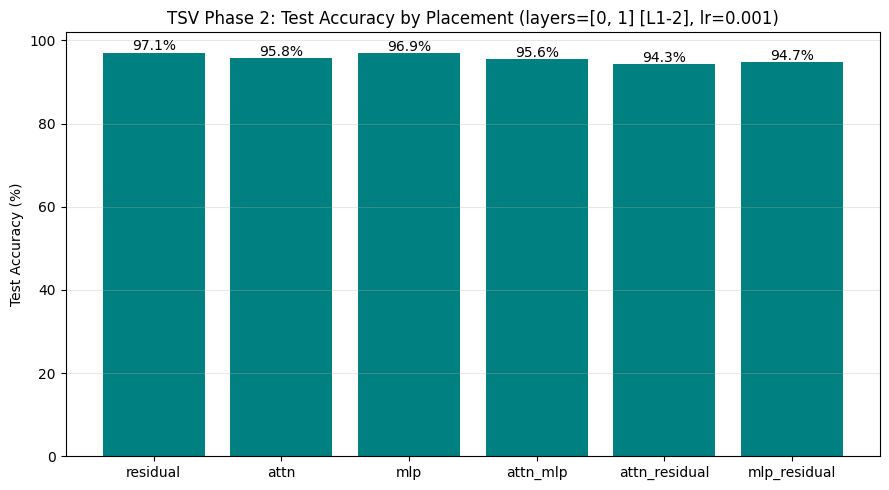


All Phase 2 results, sorted:
  where=residual        acc=97.10%  f1=0.9710  params=9,226
  where=mlp             acc=96.90%  f1=0.9689  params=9,226
  where=attn            acc=95.80%  f1=0.9579  params=9,226
  where=attn_mlp        acc=95.60%  f1=0.9558  params=10,762
  where=mlp_residual    acc=94.70%  f1=0.9468  params=10,762
  where=attn_residual   acc=94.30%  f1=0.9429  params=10,762


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
names = [r['name'] for r in phase2_results]
accs = [r['test_acc'] for r in phase2_results]
bars = ax.bar(names, accs, color='teal')
ax.set_title(f"TSV Phase 2: Test Accuracy by Placement (layers={best_layers} [{best_layers_name}], lr={best_lr})")
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3, axis='y')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center')
plt.tight_layout()
plt.savefig('tsv_phase2_where.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll Phase 2 results, sorted:")
for r in sorted(phase2_results, key=lambda r: -r['test_acc']):
    print(f"  where={r['where']:<15} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}  params={r['trainable_params']:,}")


### Phase 3: Steering Strength (`lam`) Sweep (5 runs, best layer grouping + placement + learning rate from Phases 1-2, `EPOCHS=10`)

In [22]:
best_where = best_phase2['where']
phase3_results = []

print("="*70)
print(f"PHASE 3: STEERING STRENGTH SWEEP  (layers={best_layers} [{best_layers_name}], where='{best_where}', lr={best_lr}, epochs={EPOCHS})")
print("="*70)

phase3_start = time.time()
for lam in lams:
    print(f"\n--- lam={lam} ---")
    result = run_tsv_experiment(layer_indices=best_layers, where=best_where, lam=lam, epochs=EPOCHS, lr=best_lr)
    result['name'] = f'lam={lam}'
    phase3_results.append(result)

phase3_elapsed = time.time() - phase3_start
print(f"\nPhase 3 total time: {phase3_elapsed/60:.1f} minutes")

best_phase3 = max(phase3_results, key=lambda r: r['test_acc'])
print(f"\nBest steering strength: lam={best_phase3['lam']} -> {best_phase3['test_acc']:.2f}% acc, F1={best_phase3['test_f1']:.4f}")


PHASE 3: STEERING STRENGTH SWEEP  (layers=[0, 1] [L1-2], where='residual', lr=0.001, epochs=10)

--- lam=0.1 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
visual_projection.weight                                     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

      epoch 1/10: train_loss=1.1595  train_acc=81.96%


      epoch 2/10: train_loss=0.4000  train_acc=92.70%


...

      epoch 7/10: train_loss=0.1543  train_acc=95.64%


      epoch 8/10: train_loss=0.1597  train_acc=95.04%


      epoch 9/10: train_loss=0.1750  train_acc=94.64%


      epoch 10/10: train_loss=0.1577  train_acc=94.92%


    layers=[0, 1]  where=residual  lam=10  lr=0.001  -> acc=95.80%  f1=0.9580  (82.1s)

Phase 3 total time: 7.0 minutes

Best steering strength: lam=1 -> 96.80% acc, F1=0.9680


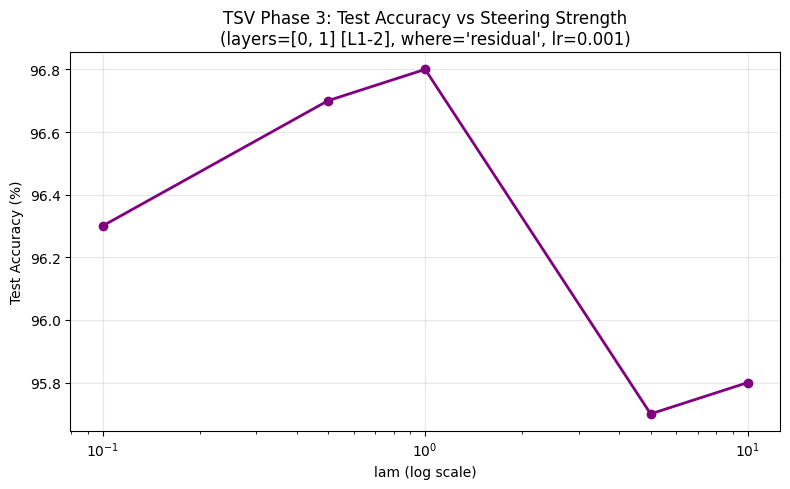


All Phase 3 results:
  lam=0.1    acc=96.30%  f1=0.9629
  lam=0.5    acc=96.70%  f1=0.9669
  lam=1      acc=96.80%  f1=0.9680
  lam=5      acc=95.70%  f1=0.9571
  lam=10     acc=95.80%  f1=0.9580


In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = [r['lam'] for r in phase3_results]
ys = [r['test_acc'] for r in phase3_results]
ax.plot(xs, ys, marker='o', linewidth=2, color='purple')
ax.set_xscale('log')
ax.set_title(f"TSV Phase 3: Test Accuracy vs Steering Strength\n(layers={best_layers} [{best_layers_name}], where='{best_where}', lr={best_lr})")
ax.set_xlabel('lam (log scale)')
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsv_phase3_lam.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll Phase 3 results:")
for r in phase3_results:
    print(f"  lam={r['lam']:<6} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}")


### Summary: Best TSV Configuration Found, and Saving All Results

In [24]:
best_lam = best_phase3['lam']
all_tsv_study_results = phase1_results + phase2_results + phase3_results
best_overall = max(all_tsv_study_results, key=lambda r: r['test_acc'])

total_study_time = phase1_elapsed + phase2_elapsed + phase3_elapsed

print("="*70)
print("BEST TSV CONFIGURATION FOUND")
print("="*70)
print(f"Layers:            {best_overall['layer_indices']}")
print(f"Placement (where): {best_overall['where']}")
print(f"Steering strength: {best_overall['lam']}")
print(f"Learning rate:     {best_overall.get('lr', best_lr)}")
print(f"Epochs:            {EPOCHS}")
print(f"Test Accuracy:     {best_overall['test_acc']:.2f}%")
print(f"Test F1:           {best_overall['test_f1']:.4f}")
print(f"Trainable params:  {best_overall['trainable_params']:,}")
print(f"\nTotal study time: {total_study_time/60:.1f} minutes "
      f"({len(all_tsv_study_results)} runs: {len(phase1_results)} layer x LR + "
      f"{len(phase2_results)} placement + {len(phase3_results)} strength)")

# Save everything to Drive
from pathlib import Path
import json, shutil

results_dir = Path('/content/drive/MyDrive/PEFT_Results')
results_dir.mkdir(exist_ok=True)

tsv_study_summary = {
    'phase1_layer_lr_groupings': phase1_results,
    'phase2_where': phase2_results,
    'phase3_lam': phase3_results,
    'best_overall': best_overall,
    'total_time_minutes': total_study_time / 60,
}

# Timestamped (permanent record) + "latest" (stable pointer for other notebooks to load)
with open(results_dir / save_name('tsv_full_study', 'json'), 'w') as f:
    json.dump(tsv_study_summary, f, indent=2)
for fname, base in [('tsv_phase1_layer_groupings.png', 'tsv_phase1_layer_groupings'),
                     ('tsv_phase2_where.png', 'tsv_phase2_where'),
                     ('tsv_phase3_lam.png', 'tsv_phase3_lam')]:
    shutil.copy(fname, results_dir / save_name(base, 'png'))

print(f"\n✓ Full TSV study (results + all 3 graphs) saved to {results_dir}")
print(f"  Timestamped: {save_name('tsv_full_study', 'json')}")


BEST TSV CONFIGURATION FOUND
Layers:            [0, 1]
Placement (where): residual
Steering strength: 5.0
Learning rate:     0.001
Epochs:            10
Test Accuracy:     97.10%
Test F1:           0.9709
Trainable params:  9,226

Total study time: 141.8 minutes (119 runs: 108 layer x LR + 6 placement + 5 strength)

✓ Full TSV study (results + all 3 graphs) saved to /content/drive/MyDrive/PEFT_Results
  Timestamped: tsv_full_study_cifar10_20260729_055227.json


## 5.2 Data & Optimization Sweep: Training Set Size and Batch Size

Two more practical questions, using whatever **layer grouping, placement,
strength, and learning rate** the study above found best -- all now run
at the same `EPOCHS=10` as everything else.

(The separate learning-rate sweep that used to live here is gone -- LR is
now tested properly, per layer grouping, back in Phase 1.)

- **Training set size** -- how many labeled images does TSV actually
  need?
- **Batch size** -- does it change final accuracy, not just speed?

In [25]:
sweep_layers = best_layers
sweep_where = best_where
sweep_lam = best_lam

print(f"Using best-found TSV configuration for both sweeps below:")
print(f"  layers={sweep_layers}  where='{sweep_where}'  lam={sweep_lam}  lr={best_lr}  epochs={EPOCHS}")


Using best-found TSV configuration for both sweeps below:
  layers=[0, 1]  where='residual'  lam=1  lr=0.001  epochs=10


### Phase 4: Training Set Size Sweep (5 runs, `EPOCHS=10`) -- how much labeled data does TSV need?

In [26]:
train_sizes = [100, 500, 1000, 2500, 5000]  # 5000 = the full subset this notebook uses
phase4_results = []

print("="*70)
print(f"PHASE 4: TRAINING SET SIZE SWEEP  (layers={sweep_layers}, where='{sweep_where}', lam={sweep_lam}, lr={best_lr}, epochs={EPOCHS})")
print("="*70)

phase4_start = time.time()
for size in train_sizes:
    print(f"\n--- train_size={size} ---")
    if size < len(train_dataset):
        size_subset, _ = random_split(train_dataset, [size, len(train_dataset) - size])
    else:
        size_subset = train_dataset
    size_loader = DataLoader(size_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

    result = run_tsv_experiment(sweep_layers, sweep_where, sweep_lam, EPOCHS, best_lr, size_loader)
    result['train_size'] = size
    phase4_results.append(result)

phase4_elapsed = time.time() - phase4_start
print(f"\nPhase 4 total time: {phase4_elapsed/60:.1f} minutes")

best_phase4 = max(phase4_results, key=lambda r: r['test_acc'])
print(f"\nBest training set size: {best_phase4['train_size']} -> {best_phase4['test_acc']:.2f}% acc")


PHASE 4: TRAINING SET SIZE SWEEP  (layers=[0, 1], where='residual', lam=1, lr=0.001, epochs=10)

--- train_size=100 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
visual_projection.weight                                     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

      epoch 1/10: train_loss=2.3052  train_acc=6.00%


      epoch 2/10: train_loss=2.1837  train_acc=27.00%


...

      epoch 7/10: train_loss=0.1221  train_acc=96.36%


      epoch 8/10: train_loss=0.1247  train_acc=96.54%


      epoch 9/10: train_loss=0.1121  train_acc=96.44%


      epoch 10/10: train_loss=0.1068  train_acc=96.80%


    layers=[0, 1]  where=residual  lam=1  lr=0.001  -> acc=96.70%  f1=0.9668  (82.0s)

Phase 4 total time: 2.7 minutes

Best training set size: 5000 -> 96.70% acc


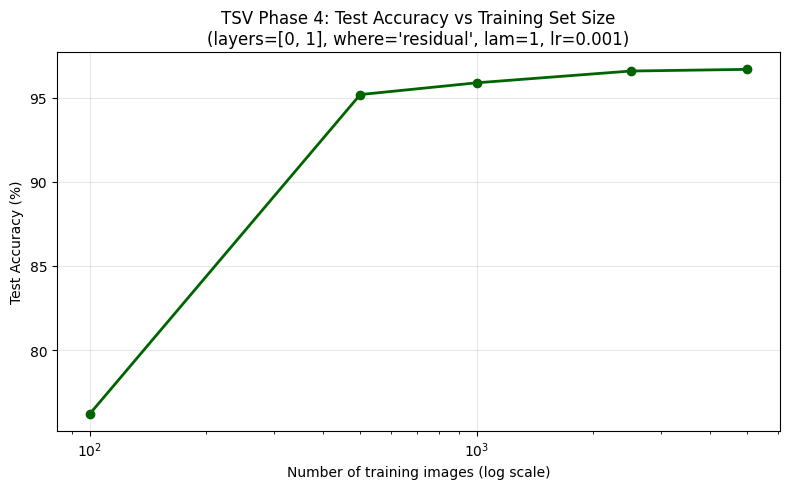


All Phase 4 results:
  train_size=100    acc=76.20%  f1=0.7607
  train_size=500    acc=95.20%  f1=0.9520
  train_size=1000   acc=95.90%  f1=0.9590
  train_size=2500   acc=96.60%  f1=0.9659
  train_size=5000   acc=96.70%  f1=0.9668


In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = [r['train_size'] for r in phase4_results]
ys = [r['test_acc'] for r in phase4_results]
ax.plot(xs, ys, marker='o', linewidth=2, color='darkgreen')
ax.set_xscale('log')
ax.set_title(f"TSV Phase 4: Test Accuracy vs Training Set Size\n(layers={sweep_layers}, where='{sweep_where}', lam={sweep_lam}, lr={best_lr})")
ax.set_xlabel('Number of training images (log scale)')
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsv_phase4_train_size.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll Phase 4 results:")
for r in phase4_results:
    print(f"  train_size={r['train_size']:<6} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}")


### Phase 5: Batch Size Sweep (4 runs, `EPOCHS=10`)

In [28]:
batch_sizes = [16, 32, 64, 128]
phase5_results = []

print("="*70)
print(f"PHASE 5: BATCH SIZE SWEEP  (layers={sweep_layers}, where='{sweep_where}', lam={sweep_lam}, lr={best_lr}, epochs={EPOCHS})")
print("="*70)

phase5_start = time.time()
for bs in batch_sizes:
    print(f"\n--- batch_size={bs} ---")
    bs_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, num_workers=2, pin_memory=True)

    result = run_tsv_experiment(sweep_layers, sweep_where, sweep_lam, EPOCHS, best_lr, bs_loader)
    result['batch_size'] = bs
    phase5_results.append(result)

phase5_elapsed = time.time() - phase5_start
print(f"\nPhase 5 total time: {phase5_elapsed/60:.1f} minutes")

best_phase5 = max(phase5_results, key=lambda r: r['test_acc'])
print(f"\nBest batch size: {best_phase5['batch_size']} -> {best_phase5['test_acc']:.2f}% acc")


PHASE 5: BATCH SIZE SWEEP  (layers=[0, 1], where='residual', lam=1, lr=0.001, epochs=10)

--- batch_size=16 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
visual_projection.weight                                     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

      epoch 1/10: train_loss=0.5704  train_acc=90.06%


      epoch 2/10: train_loss=0.1733  train_acc=95.54%


...

      epoch 7/10: train_loss=0.1564  train_acc=96.02%


      epoch 8/10: train_loss=0.1444  train_acc=96.10%


      epoch 9/10: train_loss=0.1443  train_acc=95.78%


      epoch 10/10: train_loss=0.1318  train_acc=96.28%


    layers=[0, 1]  where=residual  lam=1  lr=0.001  -> acc=96.50%  f1=0.9649  (78.0s)

Phase 5 total time: 5.6 minutes

Best batch size: 64 -> 96.80% acc


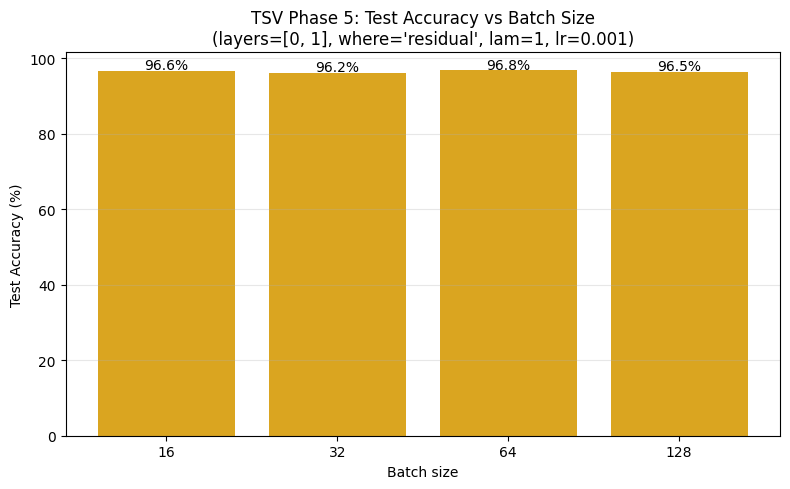


All Phase 5 results:
  batch_size=16    acc=96.60%  f1=0.9659  time=93.9s
  batch_size=32    acc=96.20%  f1=0.9619  time=82.1s
  batch_size=64    acc=96.80%  f1=0.9679  time=76.9s
  batch_size=128   acc=96.50%  f1=0.9649  time=78.0s


In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
names = [str(r['batch_size']) for r in phase5_results]
accs = [r['test_acc'] for r in phase5_results]
bars = ax.bar(names, accs, color='goldenrod')
ax.set_title(f"TSV Phase 5: Test Accuracy vs Batch Size\n(layers={sweep_layers}, where='{sweep_where}', lam={sweep_lam}, lr={best_lr})")
ax.set_xlabel('Batch size')
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3, axis='y')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center')
plt.tight_layout()
plt.savefig('tsv_phase5_batch_size.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll Phase 5 results:")
for r in phase5_results:
    print(f"  batch_size={r['batch_size']:<5} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}  time={r['time_seconds']:.1f}s")


### Phase 4-5 Summary: Saving Results

In [30]:
from pathlib import Path
import shutil

results_dir = Path('/content/drive/MyDrive/PEFT_Results')
results_dir.mkdir(exist_ok=True)

param_sweep_summary = {
    'fixed_config': {'layers': sweep_layers, 'where': sweep_where, 'lam': sweep_lam, 'lr': best_lr, 'epochs': EPOCHS},
    'phase4_train_size': phase4_results,
    'phase5_batch_size': phase5_results,
    'best_train_size': best_phase4['train_size'],
    'best_batch_size': best_phase5['batch_size'],
}

with open(results_dir / save_name('tsv_param_sweep', 'json'), 'w') as f:
    json.dump(param_sweep_summary, f, indent=2)
for fname, base in [('tsv_phase4_train_size.png', 'tsv_phase4_train_size'),
                     ('tsv_phase5_batch_size.png', 'tsv_phase5_batch_size')]:
    shutil.copy(fname, results_dir / save_name(base, 'png'))

total_sweep_time = phase4_elapsed + phase5_elapsed
print(f"Total Phase 4-5 time: {total_sweep_time/60:.1f} minutes "
      f"({len(train_sizes)+len(batch_sizes)} runs)")
print(f"\n✓ Parameter sweep results + graphs saved to {results_dir}")


Total Phase 4-5 time: 8.4 minutes (9 runs)

✓ Parameter sweep results + graphs saved to /content/drive/MyDrive/PEFT_Results


## 5.3 Parameter Efficiency Analysis

The whole point of TSV (and PEFT methods generally) is accuracy **per
trainable parameter**, not just raw accuracy. This section costs almost
nothing extra:

- It reuses `phase1_results` and `phase2_results` from the study above --
  no new training needed, since `trainable_params` was already recorded
  for every one of those 114 runs (108 from Phase 1's layer x LR grid + 6 from Phase 2).
- It adds exactly **one new run**: a **linear probe** baseline --
  `layer_indices=[]` means TSV registers zero hooks and zero steering
  vectors, so this trains *only* the classifier head on frozen CLIP
  features. This tells us how much of TSV's accuracy is actually coming
  from the steering vector itself, versus just having a trained
  classifier on top of frozen features.

In [31]:
print("="*70)
print("LINEAR PROBE BASELINE  (layer_indices=[] -- zero TSV vectors, classifier only)")
print("="*70)

linear_probe_result = run_tsv_experiment(layer_indices=[], where='residual', lam=0.0, epochs=EPOCHS, lr=best_lr)
linear_probe_result['name'] = 'Linear Probe (0 TSV params)'

print(f"\nLinear probe: acc={linear_probe_result['test_acc']:.2f}%  "
      f"f1={linear_probe_result['test_f1']:.4f}  "
      f"trainable_params={linear_probe_result['trainable_params']:,} (classifier head only)")


LINEAR PROBE BASELINE  (layer_indices=[] -- zero TSV vectors, classifier only)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
visual_projection.weight                                     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

      epoch 1/10: train_loss=1.1897  train_acc=80.40%


      epoch 2/10: train_loss=0.4671  train_acc=91.72%


...

      epoch 7/10: train_loss=0.2225  train_acc=94.10%


      epoch 8/10: train_loss=0.2129  train_acc=93.64%


      epoch 9/10: train_loss=0.1965  train_acc=94.18%


      epoch 10/10: train_loss=0.1903  train_acc=94.68%


    layers=[]  where=residual  lam=0.0  lr=0.001  -> acc=95.00%  f1=0.9499  (53.2s)

Linear probe: acc=95.00%  f1=0.9499  trainable_params=7,690 (classifier head only)


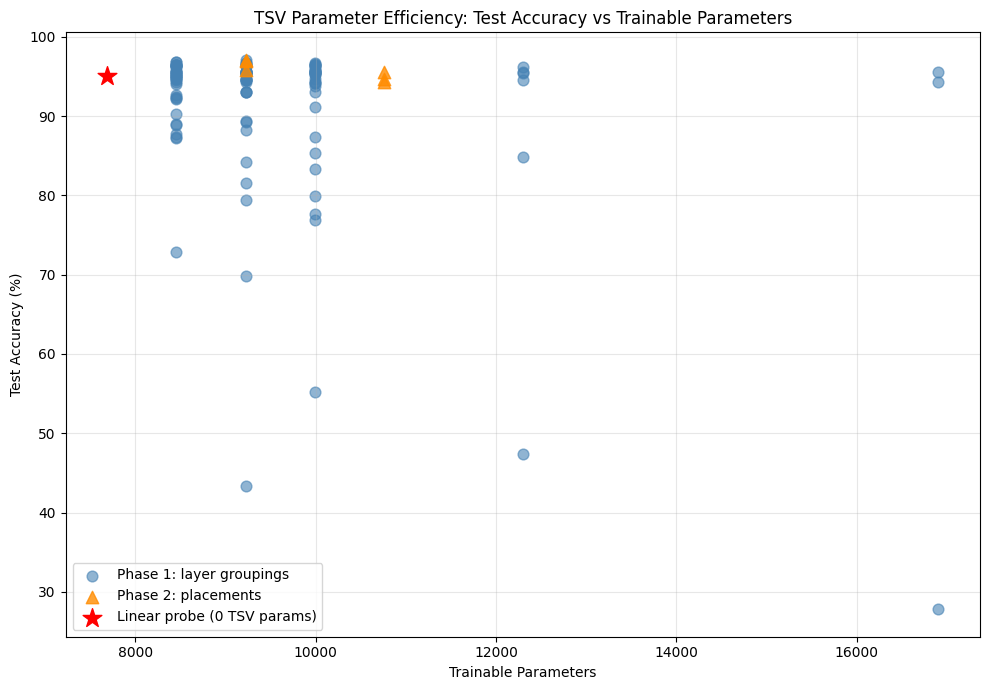


Linear probe (0 TSV params) baseline accuracy: 95.00%

Config                    Params     Acc      Acc gain over probe  Gain per 1K params  
-------------------------------------------------------------------------------------
L1                        8,458      96.80    1.80                 2.344               
L4                        8,458      96.80    1.80                 2.344               
L2                        8,458      96.50    1.50                 1.953               
L2                        8,458      96.40    1.40                 1.823               
L3                        8,458      96.40    1.40                 1.823               
L5                        8,458      96.40    1.40                 1.823               
L1                        8,458      96.30    1.30                 1.693               
L3                        8,458      96.30    1.30                 1.693               
L4                        8,458      96.20    1.20                

In [32]:
# Combine everything we have trainable_params + test_acc for: Phase 1
# (layer groupings), Phase 2 (placements), and the linear probe baseline.
all_efficiency_results = phase1_results + phase2_results + [linear_probe_result]

fig, ax = plt.subplots(figsize=(10, 7))

phase1_params = [r['trainable_params'] for r in phase1_results]
phase1_accs = [r['test_acc'] for r in phase1_results]
ax.scatter(phase1_params, phase1_accs, alpha=0.6, s=60, color='steelblue', label='Phase 1: layer groupings')

phase2_params = [r['trainable_params'] for r in phase2_results]
phase2_accs = [r['test_acc'] for r in phase2_results]
ax.scatter(phase2_params, phase2_accs, alpha=0.8, s=80, color='darkorange', marker='^', label='Phase 2: placements')

ax.scatter([linear_probe_result['trainable_params']], [linear_probe_result['test_acc']],
           s=200, color='red', marker='*', label='Linear probe (0 TSV params)', zorder=5)

ax.set_xlabel('Trainable Parameters')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('TSV Parameter Efficiency: Test Accuracy vs Trainable Parameters')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tsv_parameter_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

# Efficiency ranking: accuracy gained per 1,000 trainable parameters,
# measured above the linear-probe floor (so it reflects what the STEERING
# VECTOR itself is contributing, not the classifier head every config shares).
baseline_acc = linear_probe_result['test_acc']
print(f"\nLinear probe (0 TSV params) baseline accuracy: {baseline_acc:.2f}%\n")

print(f"{'Config':<25} {'Params':<10} {'Acc':<8} {'Acc gain over probe':<20} {'Gain per 1K params':<20}")
print("-" * 85)
for r in sorted(phase1_results + phase2_results, key=lambda r: -(r['test_acc'] - baseline_acc) / max(r['trainable_params'] - linear_probe_result['trainable_params'], 1)):
    name = r.get('name', r.get('where', '?'))
    extra_params = r['trainable_params'] - linear_probe_result['trainable_params']
    acc_gain = r['test_acc'] - baseline_acc
    gain_per_1k = (acc_gain / extra_params) * 1000 if extra_params > 0 else 0
    print(f"{str(name):<25} {r['trainable_params']:<10,} {r['test_acc']:<8.2f} {acc_gain:<20.2f} {gain_per_1k:<20.3f}")


In [33]:
from pathlib import Path
import shutil

results_dir = Path('/content/drive/MyDrive/PEFT_Results')
results_dir.mkdir(exist_ok=True)

efficiency_summary = {
    'linear_probe_baseline': linear_probe_result,
    'phase1_layer_groupings': phase1_results,
    'phase2_where': phase2_results,
}

with open(results_dir / save_name('tsv_parameter_efficiency', 'json'), 'w') as f:
    json.dump(efficiency_summary, f, indent=2)
shutil.copy('tsv_parameter_efficiency.png', results_dir / save_name('tsv_parameter_efficiency', 'png'))

print(f"✓ Parameter efficiency analysis + graph saved to {results_dir}")


✓ Parameter efficiency analysis + graph saved to /content/drive/MyDrive/PEFT_Results


## 6. TSV Method Characteristics

In [34]:
print("\n" + "="*80)
print("TSV METHOD ANALYSIS")
print("="*80)

analysis = """
### TSV (Trainable Steering Vector)
- **Principle**: Adds one trainable vector to the residual stream (or
  attention/MLP output) at a chosen transformer block, steering the whole
  downstream representation without touching any of the backbone's own weights
- **Key Features**:
  * No Linear-layer targeting decision needed -- one vector per steered layer
  * Backbone stays entirely frozen; only the vector(s) + classifier head train
  * Placement (attn / mlp / residual / combinations) and layer position are
    free design choices, explored in the full study above
- **Advantages**:
  * Extremely small number of trainable parameters (thousands, not millions)
  * Simple mechanism (forward hook, no weight-matrix decomposition)
  * No target-module search needed, unlike LoRA-style methods
- **Sensitivities** (from the full study above):
  * Steering strength (`lam`) matters a lot -- too small has no effect,
    too large destroys the representation
  * Steering too many layers at once can hurt more than help
  * Layer position and placement both affect performance meaningfully
"""

print(analysis)



TSV METHOD ANALYSIS

### TSV (Trainable Steering Vector)
- **Principle**: Adds one trainable vector to the residual stream (or
  attention/MLP output) at a chosen transformer block, steering the whole
  downstream representation without touching any of the backbone's own weights
- **Key Features**:
  * No Linear-layer targeting decision needed -- one vector per steered layer
  * Backbone stays entirely frozen; only the vector(s) + classifier head train
  * Placement (attn / mlp / residual / combinations) and layer position are
    free design choices, explored in the full study above
- **Advantages**:
  * Extremely small number of trainable parameters (thousands, not millions)
  * Simple mechanism (forward hook, no weight-matrix decomposition)
  * No target-module search needed, unlike LoRA-style methods
- **Sensitivities** (from the full study above):
  * Steering strength (`lam`) matters a lot -- too small has no effect,
    too large destroys the representation
  * Steering too man

## 7. Checkpoint Management and Inference

In [35]:
print("Loading saved TSV checkpoint for inference...")

try:
    # Rebuild a TSV model with the SAME layer_indices / where / lam used for
    # the checkpoint you want to reload -- these must match what you trained,
    # since the hook locations are set up at construction time, not restored
    # automatically from the saved state dict.
    tsv_inference_model = TSVClassificationModel(
        model_name=OPENCLIP_MODEL_NAME,
        num_classes=10,
        layer_indices=None,   # <- match whatever you trained with
        lam=5.0,
        where='residual'
    ).to(device)

    tsv_inference_model.tsv.load_state_dict(torch.load('./tsv_best_model/tsv_vectors.pth', map_location=device))
    tsv_inference_model.classifier.load_state_dict(torch.load('./tsv_best_model/classifier_head.pth', map_location=device))

    tsv_inference_model.eval()
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, test_f1 = evaluate(tsv_inference_model, test_loader, criterion, device)

    print(f"\nTSV Inference Results:")
    print(f"  Test Loss: {test_loss:.4f}")
    print(f"  Test Accuracy: {test_acc:.2f}%")
    print(f"  Test F1-Score: {test_f1:.4f}")
    print("\n✓ Successfully loaded and evaluated TSV checkpoint!")
except Exception as e:
    print(f"Note: Checkpoint loading example (optional). Error: {e}")


Loading saved TSV checkpoint for inference...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
visual_projection.weight                                     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11


TSV Inference Results:
  Test Loss: 0.1060
  Test Accuracy: 96.10%
  Test F1-Score: 0.9610

✓ Successfully loaded and evaluated TSV checkpoint!


## 8. Export and Deployment Instructions

In [36]:
deployment_guide = """
# DEPLOYMENT GUIDE (TSV)

## Saving a TSV steering vector + classifier head
```python
os.makedirs('./tsv_best_model', exist_ok=True)
torch.save(tsv_model.tsv.state_dict(), './tsv_best_model/tsv_vectors.pth')
torch.save(tsv_model.classifier.state_dict(), './tsv_best_model/classifier_head.pth')
```

## Loading it back
```python
tsv_model = TSVClassificationModel(
    model_name=OPENCLIP_MODEL_NAME, num_classes=10,
    layer_indices=[4], lam=5.0, where='residual'   # must match training config
).to(device)
tsv_model.tsv.load_state_dict(torch.load('./tsv_best_model/tsv_vectors.pth'))
tsv_model.classifier.load_state_dict(torch.load('./tsv_best_model/classifier_head.pth'))
```

## Removing the steering (back to plain, unsteered backbone)
```python
tsv_model.tsv.remove_hooks()
```
Unlike LoRA/DoRA, there's no `merge_and_unload()` step -- TSV never modified
any backbone weights in the first place, so removing the hooks is enough.

## Inference Pipeline

```python
from torchvision.transforms import Resize
import torch

def predict(image, model, device):
    resizer = Resize((224, 224))
    image = resizer(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image)
        probs = torch.softmax(logits, dim=1)
        pred_class = logits.argmax(dim=1).item()

    return pred_class, probs.cpu().numpy()[0]
```

## Model Size
- OpenCLIP ViT-B/32 backbone: ~88M parameters (entirely frozen)
- TSV vector(s): a few KB per steered layer/placement (hidden_size=768 floats each)
- Classifier head: 768 x num_classes + num_classes params

## Performance Tips
1. Use `device_map='auto'` for automatic GPU memory management on larger backbones
2. Enable `torch.cuda.amp.autocast()` for mixed precision inference
3. Batch multiple images for better GPU utilization
4. Since the backbone is untouched, the SAME frozen backbone can be shared
   across multiple different TSV vectors (e.g. one per task) without
   duplicating the ~88M backbone parameters each time
"""

print(deployment_guide)

with open('DEPLOYMENT_GUIDE.md', 'w') as f:
    f.write(deployment_guide)

print("\n✓ Deployment guide saved to 'DEPLOYMENT_GUIDE.md'")



# DEPLOYMENT GUIDE (TSV)

## Saving a TSV steering vector + classifier head
```python
os.makedirs('./tsv_best_model', exist_ok=True)
torch.save(tsv_model.tsv.state_dict(), './tsv_best_model/tsv_vectors.pth')
torch.save(tsv_model.classifier.state_dict(), './tsv_best_model/classifier_head.pth')
```

## Loading it back
```python
tsv_model = TSVClassificationModel(
    model_name=OPENCLIP_MODEL_NAME, num_classes=10,
    layer_indices=[4], lam=5.0, where='residual'   # must match training config
).to(device)
tsv_model.tsv.load_state_dict(torch.load('./tsv_best_model/tsv_vectors.pth'))
tsv_model.classifier.load_state_dict(torch.load('./tsv_best_model/classifier_head.pth'))
```

## Removing the steering (back to plain, unsteered backbone)
```python
tsv_model.tsv.remove_hooks()
```
Unlike LoRA/DoRA, there's no `merge_and_unload()` step -- TSV never modified
any backbone weights in the first place, so removing the hooks is enough.

## Inference Pipeline

```python
from torchvision.transforms i

## 9. Summary and Key Takeaways

In [37]:
tsv_best_epoch = tsv_history['test_acc'].index(max(tsv_history['test_acc']))
tsv_best_f1 = tsv_history['test_f1'][tsv_best_epoch]

summary = f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                    TSV FINE-TUNING SUMMARY                                ║
╚════════════════════════════════════════════════════════════════════════════╝

MAIN RUN (Section 5) -- layer=auto-picked early-middle, where='residual', lam=5.0
   - Training Time: {training_time_tsv:.1f} seconds
   - Best Accuracy: {max(tsv_history['test_acc']):.2f}%
   - Best F1-Score: {tsv_best_f1:.4f}

FULL STUDY (Section 5.1) -- {len(all_tsv_study_results)} runs across 3 phases
   - Best configuration found:
       Layers:            {best_overall['layer_indices']}
       Placement (where): {best_overall['where']}
       Steering strength: {best_overall['lam']}
       Test Accuracy:     {best_overall['test_acc']:.2f}%
       Test F1:           {best_overall['test_f1']:.4f}
   - Total study time: {total_study_time/60:.1f} minutes

╔════════════════════════════════════════════════════════════════════════════╗
║                      FILES SAVED TO GOOGLE DRIVE                          ║
╚════════════════════════════════════════════════════════════════════════════╝

Location: /content/drive/MyDrive/PEFT_Results/

  • tsv_full_study.json           - All 47 runs' full results
  • tsv_phase1_layer_groupings.png
  • tsv_phase2_where.png
  • tsv_phase3_lam.png

Additional files in working directory:
  • tsv_best_model/          - Main run's TSV vector(s) + classifier head
  • DEPLOYMENT_GUIDE.md      - Inference and deployment instructions

═══════════════════════════════════════════════════════════════════════════════
"""

print(summary)

# Final summary JSON
final_summary = {
    'experiment': 'TSV_Fine_Tuning',
    'dataset': 'CIFAR-10',
    'model': OPENCLIP_MODEL_NAME,
    'configuration': {
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'train_samples': subset_size_train,
        'test_samples': subset_size_test
    },
    'main_run': {
        'best_accuracy': float(max(tsv_history['test_acc'])),
        'best_f1': float(tsv_best_f1),
        'training_time_seconds': training_time_tsv,
    },
    'full_study_best_config': best_overall,
    'full_study_total_runs': len(all_tsv_study_results),
    'timestamp': datetime.now().isoformat()
}

with open('experiment_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=2)

print("✓ Experiment summary saved to 'experiment_summary.json'")
print("\n" + "="*80)
print("ALL TSV TRAINING COMPLETE!")
print("="*80)



╔════════════════════════════════════════════════════════════════════════════╗
║                    TSV FINE-TUNING SUMMARY                                ║
╚════════════════════════════════════════════════════════════════════════════╝

MAIN RUN (Section 5) -- layer=auto-picked early-middle, where='residual', lam=5.0
   - Training Time: 85.5 seconds
   - Best Accuracy: 96.10%
   - Best F1-Score: 0.9610

FULL STUDY (Section 5.1) -- 119 runs across 3 phases
   - Best configuration found:
       Layers:            [0, 1]
       Placement (where): residual
       Steering strength: 5.0
       Test Accuracy:     97.10%
       Test F1:           0.9709
   - Total study time: 141.8 minutes

╔════════════════════════════════════════════════════════════════════════════╗
║                      FILES SAVED TO GOOGLE DRIVE                          ║
╚════════════════════════════════════════════════════════════════════════════╝

Location: /content/drive/MyDrive/PEFT_Results/

  • tsv_full_study.js

## 10. Cross-Model Verification: Does the Best Config Transfer to ViT-L/14?

Your professor's setting sheet listed both **ViT-B/32** (what everything
above used) and **ViT-L/14** as models to test. Re-running the full
119-run study on ViT-L/14 (~304M params, ~3.5x bigger than ViT-B/32) would
cost proportionally more GPU time -- so instead we run just **2 targeted
verification runs**, taking whatever configuration (including learning rate) Phases 1-3 found best
on ViT-B/32 and checking whether it still works well on the bigger model.

This mirrors what the TSV paper itself does when scaling up (LLaMA-3.1-8B
-> 70B, Qwen-2.5-7B -> 14B, Appendix E.1): the paper found the best
*relative* depth (how far through the network, as a fraction) tends to
hold across model sizes better than the best *absolute* layer number
does, since bigger models simply have more layers. So we test **both**:

1. **Literal transfer** -- reuse the exact same layer index/indices found
   best on ViT-B/32 (12 layers), unchanged, on ViT-L/14 (24 layers)
2. **Depth-matched transfer** -- rescale those layer indices to the same
   *relative* depth in ViT-L/14's 24 layers (e.g. layer 4 of 12 = 33%
   depth -> layer 8 of 24, also 33% depth)

Both runs use the same `where` and `lam` that Phases 1-3 found best,
and the same `SWEEP_EPOCHS=3` used throughout the rest of this study, so
the comparison against `best_overall`'s ViT-B/32 result stays apples-to-apples.

In [38]:
OPENCLIP_L14_MODEL_NAME = 'laion/CLIP-ViT-L-14-laion2B-s32B-b82K'

def scale_layer_indices(orig_indices, orig_num_layers, new_num_layers):
    """Rescale layer indices from one model's depth to another's,
    preserving RELATIVE depth (fraction through the network) rather than
    the absolute layer number. Works for single layers, pairs, triples,
    or any other grouping."""
    scaled = []
    for idx in orig_indices:
        relative_depth = idx / (orig_num_layers - 1) if orig_num_layers > 1 else 0
        new_idx = round(relative_depth * (new_num_layers - 1))
        scaled.append(new_idx)
    seen = set()
    result = []
    for idx in scaled:
        idx = max(0, min(idx, new_num_layers - 1))
        if idx not in seen:
            seen.add(idx)
            result.append(idx)
    return sorted(result)


# Build a throwaway L-14 model just to read its layer count / hidden size
_probe_l14 = TSVClassificationModel(model_name=OPENCLIP_L14_MODEL_NAME, num_classes=10,
                                     layer_indices=[0], lam=0.0, where='residual')
l14_num_layers = _probe_l14.backbone.config.num_hidden_layers
l14_hidden_size = _probe_l14.backbone.config.hidden_size
b32_num_layers = tsv_model.backbone.config.num_hidden_layers
del _probe_l14
torch.cuda.empty_cache()

literal_layers = sweep_layers
depth_matched_layers = scale_layer_indices(sweep_layers, b32_num_layers, l14_num_layers)

print(f"ViT-B/32: {b32_num_layers} layers, hidden_size={tsv_model.hidden_size}")
print(f"ViT-L/14: {l14_num_layers} layers, hidden_size={l14_hidden_size}")
print(f"\nBest config found on ViT-B/32: layers={sweep_layers}  where='{sweep_where}'  lam={sweep_lam}")
print(f"  -> Literal transfer to ViT-L/14:       layers={literal_layers}")
print(f"  -> Depth-matched transfer to ViT-L/14: layers={depth_matched_layers}")


config.json:   0%|          | 0.00/4.58k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.71GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-L-14-laion2B-s32B-b82K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
visual_projection.weight                                     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

ViT-B/32: 12 layers, hidden_size=768
ViT-L/14: 24 layers, hidden_size=1024

Best config found on ViT-B/32: layers=[0, 1]  where='residual'  lam=1
  -> Literal transfer to ViT-L/14:       layers=[0, 1]
  -> Depth-matched transfer to ViT-L/14: layers=[0, 2]


In [39]:
VERIFY_EPOCHS = EPOCHS  # keep identical to Phases 1-5 for a fair, apples-to-apples comparison
l14_results = {}

def run_tsv_experiment_on_model(model_name, layer_indices, where, lam, epochs, lr, verbose=True):
    """Same idea as run_tsv_experiment(), but lets you specify a different backbone checkpoint."""
    m = TSVClassificationModel(model_name=model_name, num_classes=10,
                                layer_indices=layer_indices, lam=lam, where=where).to(device)
    opt = optim.AdamW(m.trainable_parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()

    start = time.time()
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(m, train_loader, opt, crit, device, epoch, epochs)
        if verbose:
            print(f"      epoch {epoch+1}/{epochs}: train_loss={train_loss:.4f}  train_acc={train_acc:.2f}%")
    elapsed = time.time() - start

    _, test_acc, test_f1 = evaluate(m, test_loader, crit, device)
    trainable_params = sum(p.numel() for p in m.trainable_parameters())

    del m, opt
    torch.cuda.empty_cache()

    result = {'layer_indices': layer_indices, 'where': where, 'lam': lam,
              'test_acc': test_acc, 'test_f1': test_f1,
              'trainable_params': trainable_params, 'time_seconds': elapsed}
    if verbose:
        print(f"    -> acc={test_acc:.2f}%  f1={test_f1:.4f}  ({elapsed:.1f}s)")
    return result


print("="*70)
print("VIT-L/14 VERIFICATION RUNS")
print("="*70)

verify_start = time.time()

print(f"\n--- ViT-L/14, LITERAL transfer (layers={literal_layers}) ---")
l14_results['literal'] = run_tsv_experiment_on_model(
    OPENCLIP_L14_MODEL_NAME, literal_layers, sweep_where, sweep_lam, VERIFY_EPOCHS, best_lr)

print(f"\n--- ViT-L/14, DEPTH-MATCHED transfer (layers={depth_matched_layers}) ---")
l14_results['depth_matched'] = run_tsv_experiment_on_model(
    OPENCLIP_L14_MODEL_NAME, depth_matched_layers, sweep_where, sweep_lam, VERIFY_EPOCHS, best_lr)

verify_elapsed = time.time() - verify_start
print(f"\nTotal verification time: {verify_elapsed/60:.1f} minutes")


VIT-L/14 VERIFICATION RUNS

--- ViT-L/14, LITERAL transfer (layers=[0, 1]) ---


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-L-14-laion2B-s32B-b82K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
visual_projection.weight                                     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

      epoch 1/10: train_loss=0.5770  train_acc=89.00%


      epoch 2/10: train_loss=0.1254  train_acc=96.98%


...

      epoch 7/10: train_loss=0.0556  train_acc=98.38%


      epoch 8/10: train_loss=0.0442  train_acc=98.66%


      epoch 9/10: train_loss=0.0401  train_acc=98.72%


      epoch 10/10: train_loss=0.0412  train_acc=98.82%


    -> acc=98.20%  f1=0.9820  (975.2s)

Total verification time: 32.9 minutes


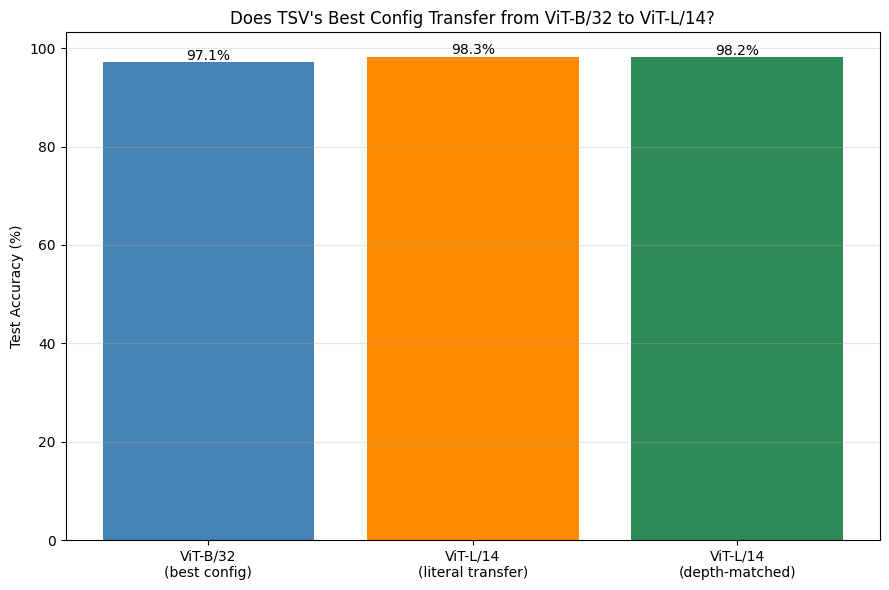

Summary:
  ViT-B/32 (layers=[0, 1], where='residual', lam=1):        97.10%
  ViT-L/14 literal transfer (layers=[0, 1]):        98.30%
  ViT-L/14 depth-matched transfer (layers=[0, 2]):  98.20%

✓ ViT-L/14 verification results + graph saved to /content/drive/MyDrive/PEFT_Results


In [40]:
# Compare against the ViT-B/32 reference (best_overall, already computed in Phase 1-3 -- no retraining needed)
comparison_names = ['ViT-B/32\n(best config)', 'ViT-L/14\n(literal transfer)', 'ViT-L/14\n(depth-matched)']
comparison_accs = [best_overall['test_acc'], l14_results['literal']['test_acc'], l14_results['depth_matched']['test_acc']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(comparison_names, comparison_accs, color=['steelblue', 'darkorange', 'seagreen'])
ax.set_title("Does TSV's Best Config Transfer from ViT-B/32 to ViT-L/14?")
ax.set_ylabel('Test Accuracy (%)')
ax.grid(True, alpha=0.3, axis='y')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center')
plt.tight_layout()
plt.savefig('tsv_l14_verification.png', dpi=150, bbox_inches='tight')
plt.show()

print("Summary:")
print(f"  ViT-B/32 (layers={sweep_layers}, where='{sweep_where}', lam={sweep_lam}):        {best_overall['test_acc']:.2f}%")
print(f"  ViT-L/14 literal transfer (layers={literal_layers}):        {l14_results['literal']['test_acc']:.2f}%")
print(f"  ViT-L/14 depth-matched transfer (layers={depth_matched_layers}):  {l14_results['depth_matched']['test_acc']:.2f}%")

# Save to Drive
from pathlib import Path
import shutil

results_dir = Path('/content/drive/MyDrive/PEFT_Results')
results_dir.mkdir(exist_ok=True)

l14_summary = {
    'vit_b32_reference': best_overall,
    'vit_l14_literal_transfer': l14_results['literal'],
    'vit_l14_depth_matched_transfer': l14_results['depth_matched'],
    'b32_num_layers': b32_num_layers,
    'l14_num_layers': l14_num_layers,
}
with open(results_dir / save_name('tsv_l14_verification', 'json'), 'w') as f:
    json.dump(l14_summary, f, indent=2)
shutil.copy('tsv_l14_verification.png', results_dir / save_name('tsv_l14_verification', 'png'))

print(f"\n✓ ViT-L/14 verification results + graph saved to {results_dir}")
